In [1]:
# loading dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\titanic dataset.zip")
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [2]:
# basic checking
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df["Survived"].unique()

array([0, 1])

In [6]:
# checking target distribution if dataset will get biased or not
# if y is imbalanced then below class will use
"""from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)"""
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [7]:
df["Survived"].dtype

dtype('int64')

In [8]:
y = df["Survived"]

In [9]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

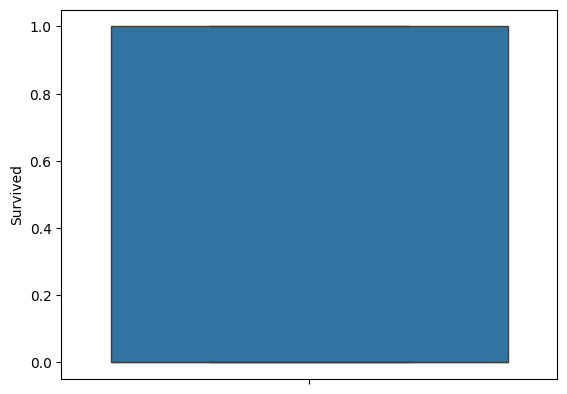

In [10]:
sns.boxplot(data = y)
plt.show()

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.drop(columns = "Cabin", inplace = True)
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [13]:
df["Age"].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [14]:
df["Age"] = df["Age"].fillna(df["Age"].mode())
print(df["Age"].isnull().sum())

177


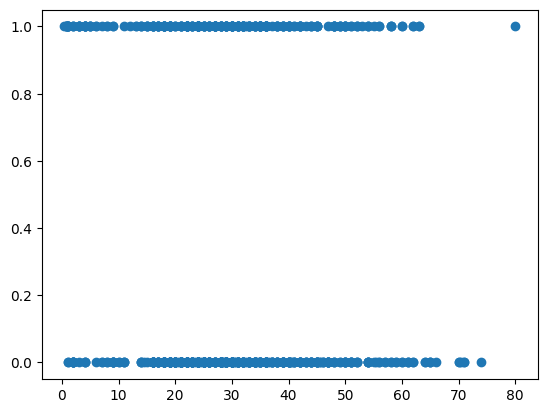

In [15]:
#sns.scatterplot(x="Age", y="Survived", data=df)
plt.scatter(data = df, x = "Age", y = "Survived")
plt.show()

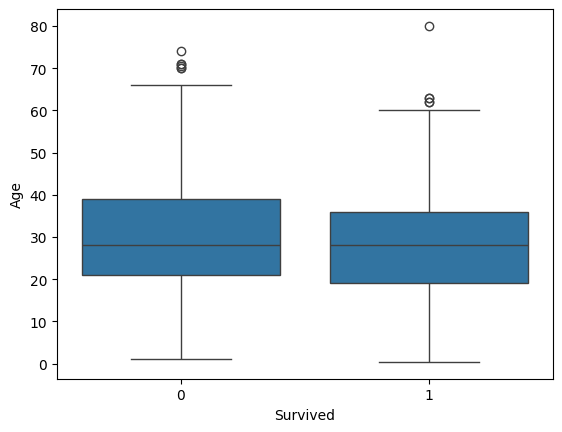

In [16]:
sns.boxplot(data  = df, x = "Survived", y = "Age")
plt.show()

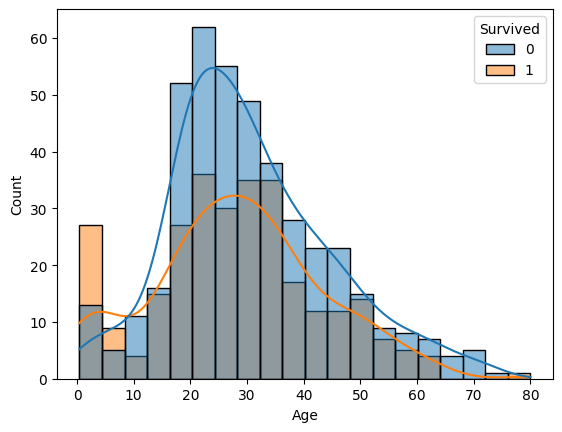

In [17]:
sns.histplot(data = df, x = "Age", hue = "Survived", kde = True)
plt.show()

In [18]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,S


In [19]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [20]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [21]:
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

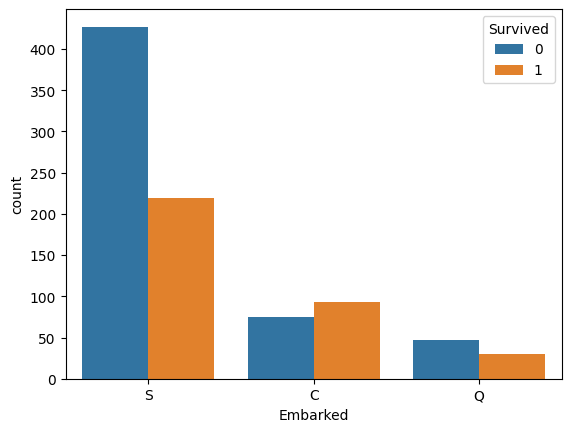

In [22]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.show()

In [23]:
df = pd.get_dummies(df, columns = ["Embarked"], drop_first = True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,False,True


In [24]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Embarked_Q"] = le.fit_transform(df["Embarked_Q"])
df["Embarked_S"] = le.fit_transform(df["Embarked_S"])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,1


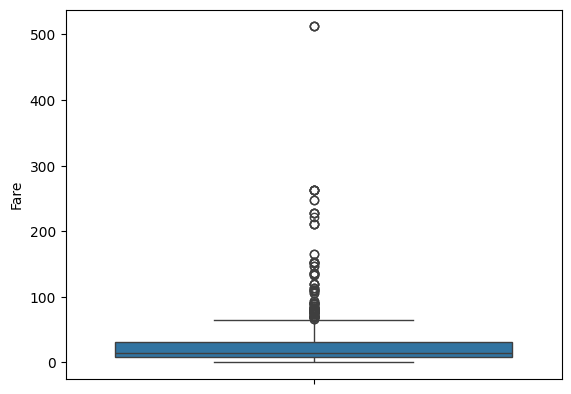

In [26]:
sns.boxplot(df["Fare"])
plt.show()

In [27]:
import numpy as np
df['Fare'] = np.log1p(df['Fare'])
df['Age'] = np.log1p(df['Age'])

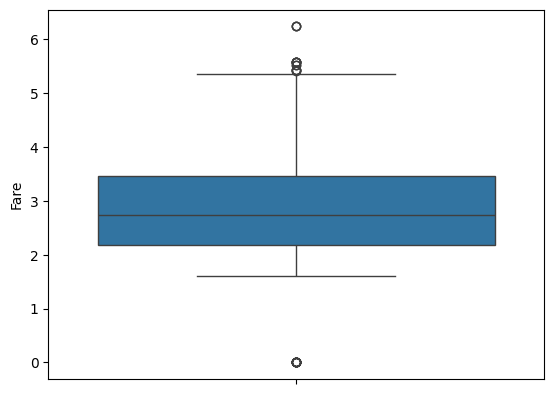

In [28]:
sns.boxplot(df["Fare"])
plt.show()

In [29]:
df["Age"] = df["Age"].fillna(df["Age"].mode()[0])
df["Age"].unique()

array([3.13549422, 3.66356165, 3.29583687, 3.58351894, 3.21887582,
       4.00733319, 1.09861229, 3.33220451, 2.7080502 , 1.60943791,
       4.07753744, 3.04452244, 3.68887945, 4.02535169, 3.4657359 ,
       3.55534806, 2.77258872, 3.36729583, 2.19722458, 2.99573227,
       3.71357207, 4.20469262, 3.76120012, 3.09104245, 2.94443898,
       1.38629436, 2.07944154, 3.91202301, 3.40119738, 4.18965474,
       3.38439026, 1.79175947, 2.48490665, 3.8286414 , 2.89037176,
       3.49650756, 2.83321334, 3.25809654, 0.60431597, 3.4339872 ,
       3.52636052, 3.17805383, 3.8501476 , 4.09434456, 4.27666612,
       3.63758616, 3.87120101, 2.74084002, 4.26969745, 3.51154544,
       2.56494936, 2.30258509, 3.62434093, 3.95124372, 4.03424064,
       3.72569343, 3.80666249, 0.69314718, 4.12713439, 4.04305127,
       3.93182563, 3.61091791, 3.83945231, 3.06805294, 4.14313473,
       3.73766962, 3.97029191, 4.15888308, 3.19867312, 0.65232519,
       3.78418963, 4.11087386, 2.39789527, 4.17438727, 2.63905

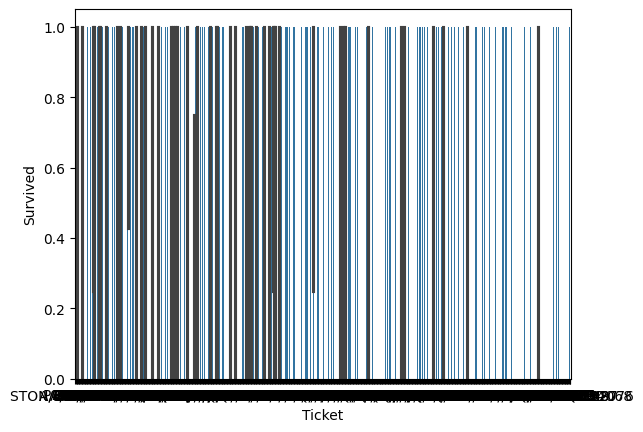

In [30]:
sns.barplot(x="Ticket",y="Survived",data=df)
plt.show()

In [31]:
df.drop(columns = "Ticket", inplace = True)
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,3.135494,1,0,2.110213,0,1


<Axes: xlabel='Name', ylabel='Survived'>

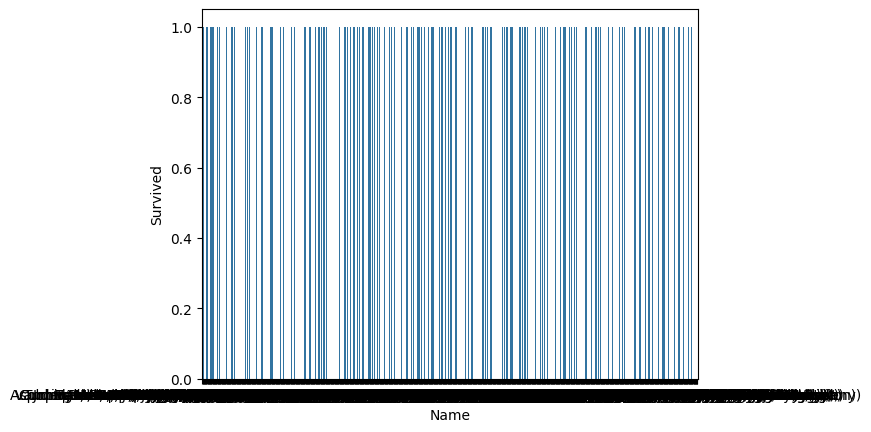

In [32]:
sns.barplot(x="Name",y="Survived",data=df)


In [33]:
df.drop(columns = "Name", inplace = True)
df.head(1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,male,3.135494,1,0,2.110213,0,1


In [34]:
df["Parch"].unique()

array([0, 1, 2, 5, 3, 4, 6])

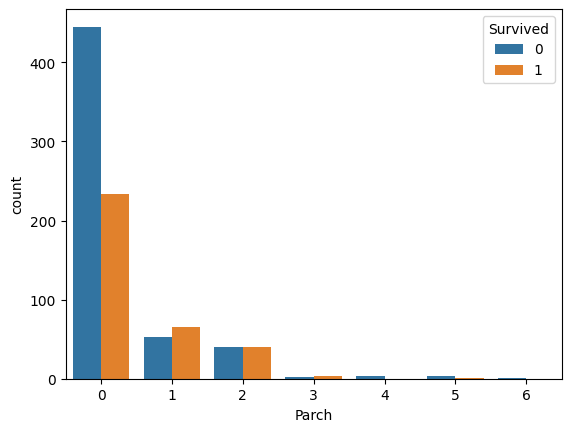

In [35]:
sns.countplot(x = "Parch", hue = "Survived", data = df)
plt.show()

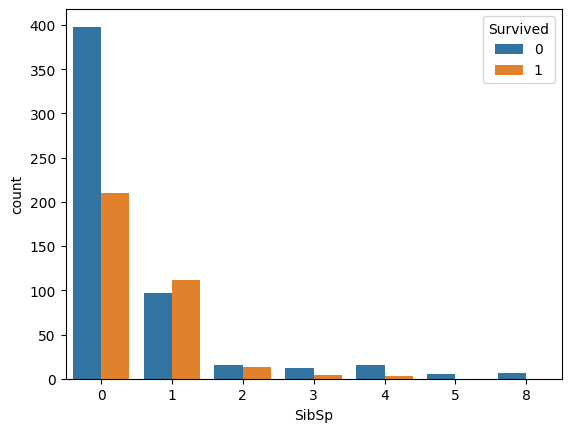

In [36]:
sns.countplot(x = "SibSp", hue = "Survived", data = df)
plt.show()

In [37]:
df.head(1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,male,3.135494,1,0,2.110213,0,1


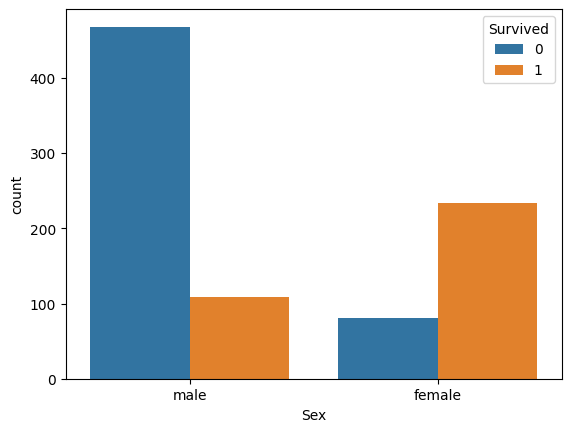

In [38]:
sns.countplot(x = "Sex", hue = "Survived", data = df)
plt.show()

In [39]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [40]:
df = pd.get_dummies(df, columns = ["Sex"], drop_first = True)
df.head(1)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male
0,1,0,3,3.135494,1,0,2.110213,0,1,True


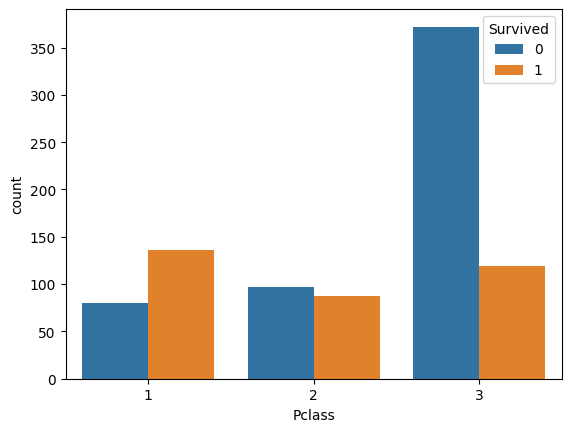

In [41]:
sns.countplot(x = "Pclass", hue = "Survived", data = df)
plt.show()

In [42]:
df["Pclass"].unique()

array([3, 1, 2])

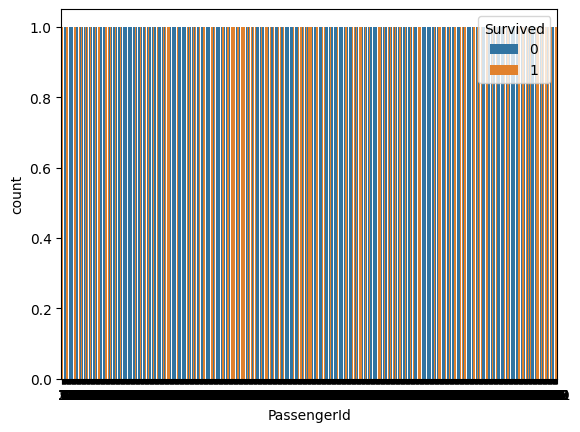

In [43]:
sns.countplot(x = "PassengerId", hue = "Survived", data = df)
plt.show()

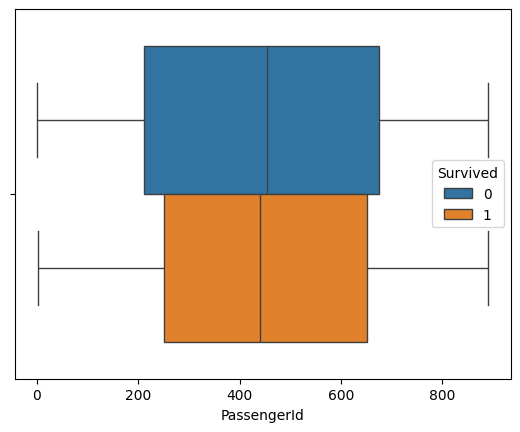

In [44]:
sns.boxplot(x = "PassengerId", hue = "Survived", data = df)
plt.show()

In [45]:
df.drop(columns = ["PassengerId"], inplace = True)
df.head(1)

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_male
0,0,3,3.135494,1,0,2.110213,0,1,True


In [46]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q',
       'Embarked_S', 'Sex_male'],
      dtype='object')

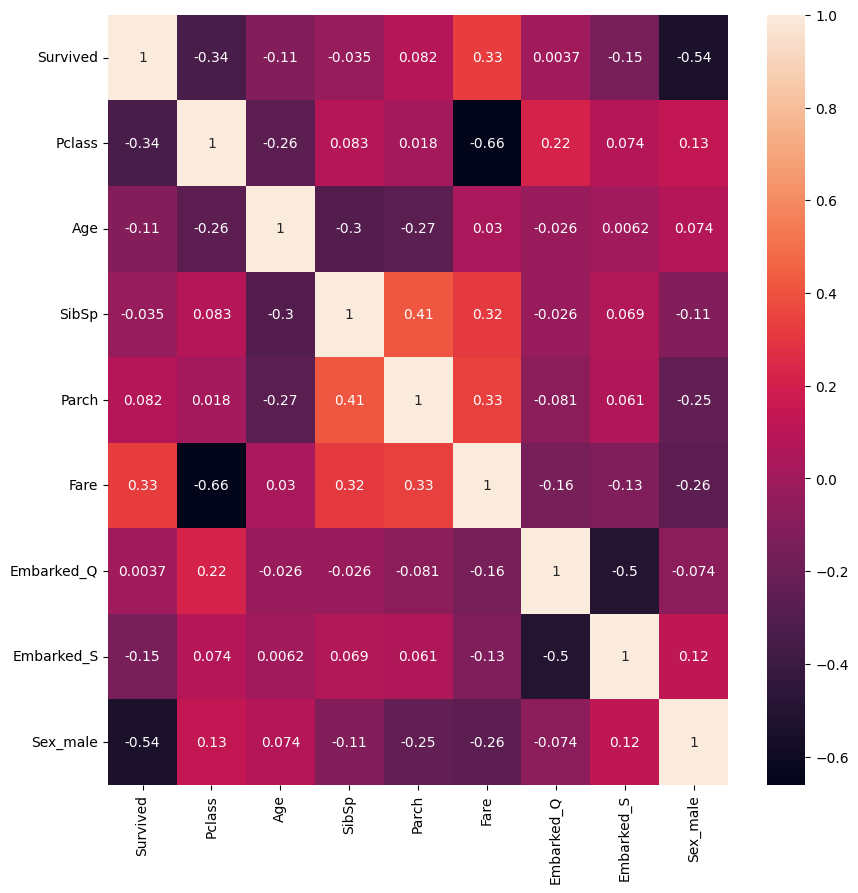

In [47]:
plt.figure(figsize = (10, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [48]:
x = df[[ 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q','Embarked_S', 'Sex_male']] 
y = df["Survived"]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)


In [49]:
x_train.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
Sex_male      0
dtype: int64

In [50]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 1000)
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
y_predict = lr.predict(x_test)

In [52]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_predict)*100)

81.00558659217877


In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

